In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# --- CHANGED SECTION START ---
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox  # <--- Moved here
# --- CHANGED SECTION END ---

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Union

In [7]:
dataset = pd.read_csv("Organic_InvasivePAV.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7775200 entries, 0 to 7775199
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   Breath_ID   int64  
 2   Time_Step   int64  
 3   Flow        float64
 4   Pressure    float64
dtypes: float64(2), int64(3)
memory usage: 296.6 MB


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Try different import locations for ljungbox
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
except ImportError:
    try:
        from statsmodels.tsa.stattools import acorr_ljungbox
    except ImportError:
        def acorr_ljungbox(x, lags, return_df=True):
            print("Warning: acorr_ljungbox not available")
            return None

class TemporalDecomposition:
    """Optimized temporal decomposition for biosignal analysis with millisecond timing."""

    def __init__(self, dataset: pd.DataFrame, bio_feature: str, time_step_col: str = None, freq: str = '20L'):
        """
        Parameters:
        - dataset: Input DataFrame
        - bio_feature: Name of the biosignal column to analyze
        - time_step_col: Column with cumulative time in milliseconds
        - freq: Frequency string ('20L' for 20ms, '50Hz' for 50Hz sampling)
        """
        if not isinstance(dataset, pd.DataFrame):
            raise TypeError("Input 'dataset' must be a pandas DataFrame.")
        if bio_feature not in dataset.columns:
            raise ValueError(f"'{bio_feature}' not found in DataFrame columns.")

        self.dataset = dataset.copy()
        self.bio_feature = bio_feature
        
        self._setup_time_index(time_step_col, freq)
        
        self.residuals = None
        self.decomposition = None
        
        sb.set_style("darkgrid")

    def _setup_time_index(self, time_step_col: str, freq: str):
        """Setup time index from cumulative milliseconds."""
        if time_step_col:
            if time_step_col not in self.dataset.columns:
                raise ValueError(f"Time step column '{time_step_col}' not found.")
            
            # Convert cumulative milliseconds to timedelta index
            time_deltas = pd.to_timedelta(self.dataset[time_step_col], unit='ms')
            
            # Create a reference start time and add the cumulative time deltas
            start_time = pd.Timestamp('2000-01-01')  # Arbitrary start point
            datetime_index = start_time + time_deltas
            
            self.dataset = self.dataset.set_index(datetime_index)
        
        # Validate and set frequency
        self.dataset = self.dataset.sort_index()
        
        # Handle frequency - convert '50Hz' to '20L' if needed
        if freq == '50Hz':
            self.freq = '20L'  # 20 milliseconds
        else:
            self.freq = freq
        
        try:
            self.dataset = self.dataset.asfreq(self.freq)
            print(f"Data indexed with {self.freq} frequency (50Hz sampling)")
        except Exception as e:
            print(f"Warning: Could not set frequency '{self.freq}': {e}")
            print("Attempting to continue with irregular index...")

    def decompose(self, period: int = None, model: str = 'additive') -> dict:
        """Decompose biosignal into components."""
        if period is None:
            # Auto-calculate period for common biological rhythms
            # For 50Hz data, common periods might be:
            # - Respiratory: ~3-5 seconds (150-250 samples)
            # - Cardiac: ~0.8-1.2 seconds (40-60 samples)
            print("No period specified. Please provide a period for decomposition.")
            print("Common periods for 50Hz biosignals:")
            print("  - Cardiac rhythm: 40-60 samples (0.8-1.2 seconds)")
            print("  - Respiratory rhythm: 150-250 samples (3-5 seconds)")
            return {}
        
        biosignal = self.dataset[self.bio_feature].dropna()
        
        if len(biosignal) < 2 * period:
            raise ValueError(f"Signal too short ({len(biosignal)}) for period {period}.")
        
        try:
            self.decomposition = seasonal_decompose(
                biosignal, model=model, period=period
            )
            self.residuals = self.decomposition.resid.dropna()
            
            print(f"Decomposition successful: period={period} ({period * 20}ms)")
            
            return {
                'trend': self.decomposition.trend,
                'seasonal': self.decomposition.seasonal,
                'resid': self.decomposition.resid,
                'observed': self.decomposition.observed
            }
        except Exception as e:
            print(f"Decomposition error: {e}")
            self.decomposition = None
            self.residuals = None
            return {}

    def suggest_periods(self):
        """Suggest possible periods based on 50Hz sampling rate."""
        suggestions = {
            'ultra_short': [10, 25, 50],      # 200ms, 500ms, 1s
            'cardiac': [40, 50, 60],          # 0.8s, 1s, 1.2s (heart rate)
            'respiratory': [150, 200, 250],   # 3s, 4s, 5s (respiration)
            'medium': [500, 750, 1000],       # 10s, 15s, 20s
            'long': [1500, 3000, 4500]        # 30s, 60s, 90s
        }
        
        print("\nSuggested periods for 50Hz data (samples → time):")
        for category, periods in suggestions.items():
            times = [f"{p} samples ({p * 20}ms)" for p in periods]
            print(f"  {category}: {', '.join(times)}")

    def plot(self, figsize=(12, 8)):
        """Plot decomposition results."""
        if self.decomposition is None:
            raise ValueError("Run decompose() first.")
        
        fig = self.decomposition.plot()
        fig.set_size_inches(figsize)
        
        # Get period in milliseconds for title
        seasonal_data = self.decomposition.seasonal
        if len(seasonal_data) > 0:
            period_ms = len(seasonal_data) * 20  # Convert samples to ms
            fig.suptitle(f'{self.bio_feature} Decomposition (Period: {period_ms}ms)', y=1.02)
        else:
            fig.suptitle(f'{self.bio_feature} Decomposition', y=1.02)
            
        plt.tight_layout()
        plt.show()

    def analyze_residuals(self, acf_lags: int = 50, pacf_lags: int = 50) -> dict:
        """Analyze residuals for stationarity and autocorrelation."""
        if self.residuals is None or self.residuals.empty:
            raise ValueError("No residuals available. Run decompose() first.")
        
        residuals = self.residuals
        
        # Plot ACF/PACF
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        plot_acf(residuals, lags=acf_lags, ax=axes[0], alpha=0.05)
        plot_pacf(residuals, lags=pacf_lags, ax=axes[1], alpha=0.05)
        plt.tight_layout()
        plt.show()
        
        # Statistical tests
        results = {}
        
        # ADF Test
        try:
            adf_result = adfuller(residuals)
            results['ADF'] = {
                'statistic': adf_result[0],
                'pvalue': adf_result[1],
                'critical_values': adf_result[4]
            }
        except Exception as e:
            print(f"ADF test failed: {e}")
            results['ADF'] = None
        
        # Ljung-Box Test
        try:
            lb_lags = min(10, len(residuals) // 4)
            lb_result = acorr_ljungbox(residuals, lags=[lb_lags], return_df=True)
            results['Ljung-Box'] = lb_result
        except Exception as e:
            print(f"Ljung-Box test not available: {e}")
            results['Ljung-Box'] = None
        
        return results

    def report(self, analysis_results: dict):
        """Generate concise analysis report."""
        print(f"\n{' BIOSIGNAL RESIDUAL ANALYSIS ':=^60}")
        print(f"Feature: {self.bio_feature}")
        print(f"Sampling: 50Hz (20ms intervals)")
        
        # ADF Results
        adf = analysis_results.get('ADF')
        if adf:
            stat, pval = adf['statistic'], adf['pvalue']
            stationarity = 'Stationary' if pval < 0.05 else 'Non-stationary'
            print(f"\nADF Test: {stationarity} (p={pval:.4f})")
        
        # Ljung-Box Results
        lb = analysis_results.get('Ljung-Box')
        if lb is not None and hasattr(lb, 'shape') and lb.shape[0] > 0:
            sig_lags = [i for i, p in enumerate(lb['lb_pvalue']) if p <= 0.05]
            if sig_lags:
                print(f"Ljung-Box: Auto-correlation detected at lags {sig_lags}")
            else:
                print("Ljung-Box: No significant auto-correlation (white noise)")
        
        print("=" * 60)

    def analyze(self, period: int = None, model: str = 'additive'):
        """Complete analysis pipeline."""
        if period is None:
            self.suggest_periods()
            return {}
        
        print(f"\nAnalyzing {self.bio_feature} at 50Hz")
        print(f"Period: {period} samples ({period * 20}ms)")
        
        # Decomposition
        decomp = self.decompose(period=period, model=model)
        if not decomp:
            return {}
        
        self.plot()
        
        # Residual analysis
        results = self.analyze_residuals()
        self.report(results)
        
        return results

/tmp/ipykernel_46194/2833561098.py:71: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  self.dataset = self.dataset.asfreq(self.freq)


Attempting to continue with irregular index...

Suggested periods for 50Hz data (samples → time):
  ultra_short: 10 samples (200ms), 25 samples (500ms), 50 samples (1000ms)
  cardiac: 40 samples (800ms), 50 samples (1000ms), 60 samples (1200ms)
  respiratory: 150 samples (3000ms), 200 samples (4000ms), 250 samples (5000ms)
  medium: 500 samples (10000ms), 750 samples (15000ms), 1000 samples (20000ms)
  long: 1500 samples (30000ms), 3000 samples (60000ms), 4500 samples (90000ms)

Analyzing Flow at 50Hz
Period: 50 samples (1000ms)
Decomposition successful: period=50 (1000ms)


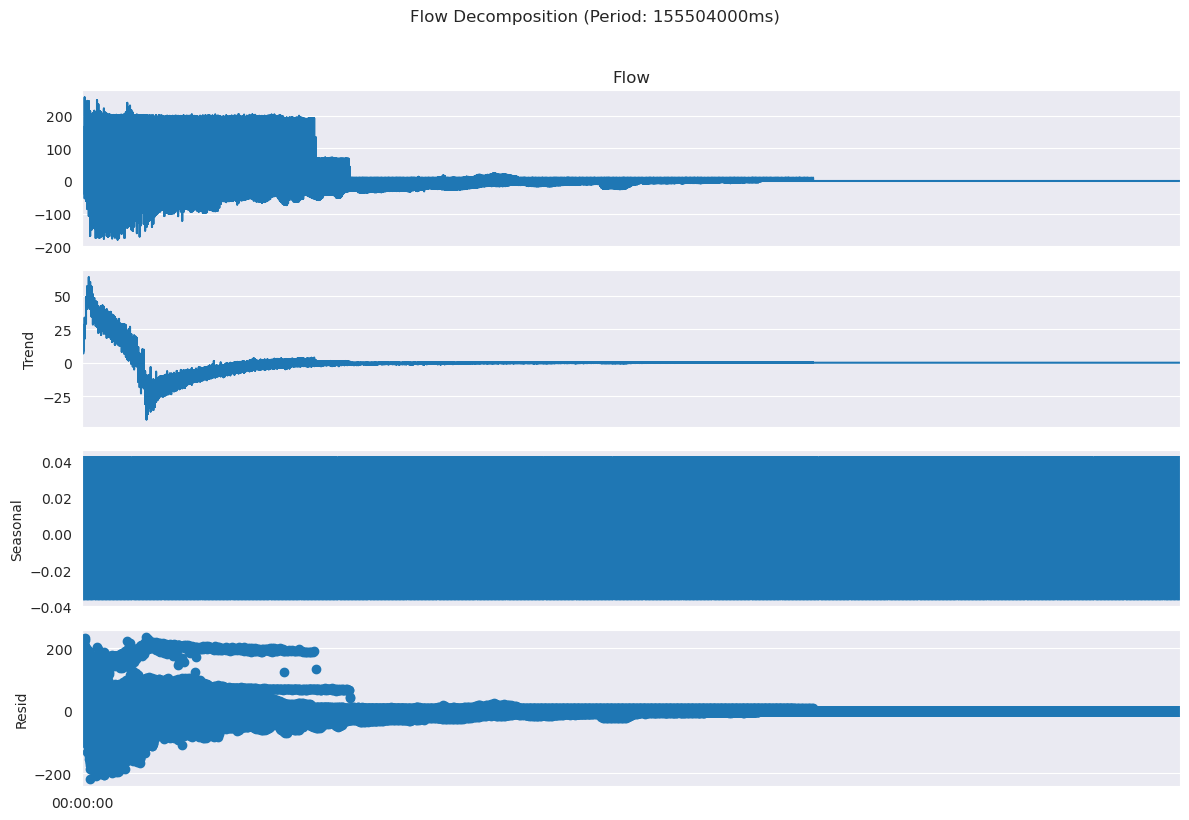

In [ ]:
# For your 50Hz data with cumulative milliseconds
td = TemporalDecomposition(
    dataset, 
    bio_feature='Flow',
    time_step_col='Time_Step',  
    freq='50Hz'  
)

# Get period suggestions based on common biological rhythms
td.suggest_periods()

# Analyze with a cardiac rhythm period (50 samples = 1 second)
results = td.analyze(period=50)

# Or respiratory rhythm (200 samples = 4 seconds)
results = td.analyze(period=200)